# Look through everything again

In [24]:
import librosa 
import librosa.display
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns
import IPython.display as idp

from glob import glob
from itertools import cycle

In [25]:
# Setting some Stylistic themes
sns.set_theme(style="white", palette=None)
color_pal = plt.rcParams["axes.prop_cycle"].by_key()["color"]
color_cycle = cycle(plt.rcParams["axes.prop_cycle"].by_key()["color"])

In [26]:
path = "C:\\\\Users\\tobyr\\OneDrive\\School\\+SeniorProject\\FinalReport\\Report\\Code\\0audio\\Actor_01\\03-01-01-01-01-01-01.wav"

In [27]:
#Play an Example of the Unedited Audio File
#idp.Audio(path)

In [28]:
# y, is the raw audio value, and sr is the sample rate
y, sr = librosa.load(path)
print(f'Y value snippet: {y}')
print(f'Size: {len(y)} (number of samples)')
print(f'Sample Rate: {sr} samples per second')

Y value snippet: [ 5.3765390e-08 -2.1233145e-08 -6.0478342e-09 ...  4.8083174e-14
 -9.6233243e-15  2.8714739e-14]
Size: 72838 (number of samples)
Sample Rate: 22050 samples per second


## Raw Audio File

<Axes: title={'center': 'Raw Audio'}>

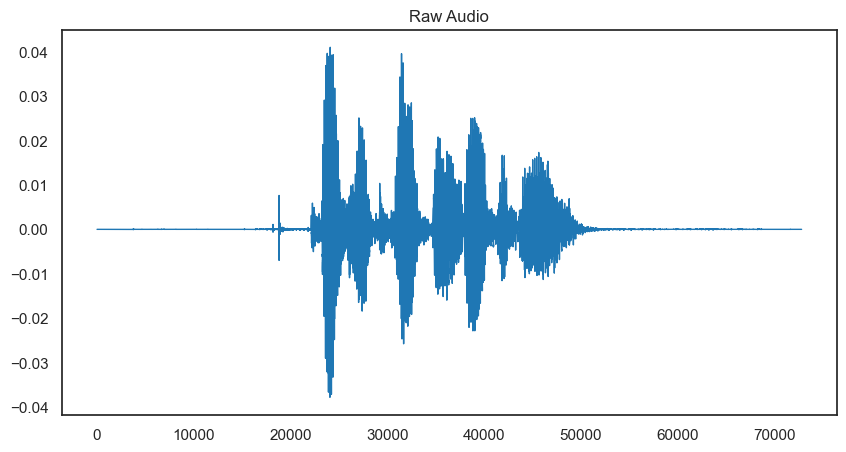

In [29]:
pd.Series(y).plot(figsize=(10,5), 
                  lw=1, 
                  title='Raw Audio')

# Defining Frames
25 ms frames, 10 ms hop, 40 dB threshold.
Since our sample is recorded/extracted at 22050 samples per second, we do a simple cross multiplication

frame_len/25 = 22050/1000

frame_len = 551.25 ≈ 551

hop_len/10 = 22050/1000

hop_len = 220.5 ≈ 220

In [30]:
# frame_len and frame_hop
frame_len = int(0.025 * sr)  # 25 ms = 400 samples @16 kHz
frame_hop = int(0.010 * sr)  # 10 ms = 160 samples

# Applying a Voice Activity Detection (VAD) Filter
Using Librosas built in split function which takes frame and hop length.

The vad filter works by using the loudest part of the audio signal and then exlcluding anything that is less than 40 db below that highest point. 

In [31]:
# Use librosa.effects.split to find non-silent intervals. This returns a 2xn array. which are the starting and stopping times of speech frames.
intervals = librosa.effects.split(y,                        
                                  top_db=40,                
                                  frame_length=frame_len,   
                                  hop_length=frame_hop)     
# Since some rhythym and natural pauses in speech can be used in speaker identification we only remove preceding and trailing silences.  
start = intervals[0][0]
end = intervals[-1][1]

In [32]:
# Stitch the intervals back into one continuous speech-only array
y_vad = np.concatenate([y[start:end]])

print(f"Original length: {len(y)/sr:.2f}s   After VAD: {len(y_vad)/sr:.2f}s")
idp.Audio(y_vad, rate=sr, normalize=False)

Original length: 3.30s   After VAD: 1.48s


<Axes: title={'center': 'Raw Audio'}>

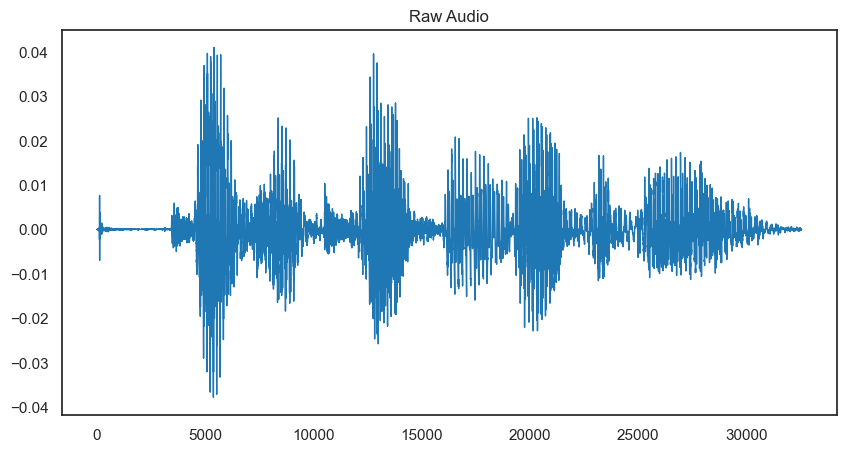

In [33]:
pd.Series(y_vad).plot(figsize=(10,5), 
                  lw=1, 
                  title='Raw Audio')

# 24-Dim Log-Mel Filterbanks

In [34]:
# Compute Mel spectrogram (power), then log-scale
mel = librosa.feature.melspectrogram(
    y=y_vad,             # 1D speech‐only waveform
    sr=sr,              
    n_fft=frame_len,     # number of sample per ast Fourier Transform (FFT) frame
    hop_length=frame_hop,# setting the Frame size
    win_length=frame_len,# setting the Hop length
    window="hann",       # Kaldi’s default “hamming/povey” style → librosa’s “hann” is fine
    center=False,        # so frames align exactly with the 25 ms/10 ms grid
    n_mels=24,
    fmin=20,
    fmax=7600
)
log_fbank = librosa.power_to_db(mel, ref=np.max)  # shape: (24, n_frames)

# Sliding-Window Mean Normalization

In [36]:
# 3-second sliding window mean normalization for log_fbank
window_size = int(3 * sr / frame_hop)  # number of frames in 3 seconds

# fbank: (n_mels, n_frames)
df = pd.DataFrame(log_fbank.T)
normalized = df.rolling(
    window=window_size,    # number of consecutive rows in each window
    min_periods=1,         # require at least 1 row to compute a mean
    center=True            # center the window on each row, rather than “trailing” or “leading”
).mean()
log_fbank_norm = (df - normalized).T.values.astype(np.float32)



array([[-37.889885 , -37.673172 , -36.13845  , ..., -16.237812 ,
        -17.054153 , -19.341396 ],
       [-48.775135 , -51.086994 , -48.80927  , ..., -17.756796 ,
        -17.210684 , -19.378939 ],
       [-51.20109  , -52.669437 , -51.41155  , ..., -21.9277   ,
        -20.07803  , -22.508678 ],
       ...,
       [ 12.4334135,  -4.0160527,  -3.8213582, ..., -18.479607 ,
        -17.29882  , -18.503868 ],
       [ 13.937334 ,   3.7740424,  -1.7245384, ..., -20.710691 ,
        -18.761732 , -21.768957 ],
       [ 17.030088 ,   8.663698 ,   3.3026261, ..., -20.097689 ,
        -17.801836 , -17.960749 ]], dtype=float32)